# Machine Learning - Knot Classification #
### Author of this Jupyter Notebook: Djordje Mihajlovic ###
Welcome to PyKnot basic! This is a Jupyter notebook exercise to introduce the user to machine learning and knots based on work done by the TAPLab. This code is built on previous work by Davide Michieletto, Joseph Sleiman, Filippo Conforto, Yair Gutierrez Fosado and Djordje Mihajlovic.

The code highlights key aspects of machine learning, with minimal coding skills required, notably;
* Data loading
* Data visualization and exploration
* Neural networks - Feed Forward & LSTM (PyTorch)
* Reducing boilerplate code (using PyTorch Lightning)
* Mitigating overfitting and improving generality (validation datasets and early stopping)
* Model performance analysis (Confusion matricies)
* Other machine learning models and methods - Decision Trees (SciKitLearn)

This code can be generalized to other projects with sufficient change in data loading and model architecture.
For each code block an explanation is included to guide the user through what is happening.

### Total: 7.5/10 ###

## Package loading ##

There is a .yaml file from which you should be able to create a conda enviornment in order to be able to run all the code below via running
```
conda env create --name ml-knots-tutorial --file=requirements.yaml
```
For the user with any experience in Python the subsequent code block is trivial.

For anyone with minimal experience in Python, the code block below is simply loading in the required packages for the code to work. These are essentially other sets of code that let us implement functions built by other people without needing to redefine them, for example in the case of machine learning, the whole process has been automated and we simply just need to know how to work with a prebuilt set of functions rather than reimplementing them ourselves (i.e. backpropagation).

In [63]:
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, Subset

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping

import matplotlib.pyplot as plt

from sklearn import tree
from sklearn import neighbors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from functions.helper_basic import *
from functions.loader_basic import *
from functions.writhe_code import *

import itertools
import pickle
from pathlib import Path

## Basic Data Loading ##
In the next block of code we would like to load in some data and play around with it abit to learn a bit more about the structure of our data. Understanding the structure of your data is essential in machine learning!

Running the code, you should get an output that tells you something about how the data is stored, specifically its shape. Data is (usually) stored via arrays (multi-dimensional matricies), so evaluating the data (for a 2D matrix) we should get a shape (height, width).

Additionally, we print the first element row of our data - for the data specifically being loaded, this represents a point in $\mathbb{R}^{3}$ given by $x$, $y$ and $z$ coordinates.

In [64]:
knot = "0_1"

file = f"data/XYZ/XYZ_{knot}_small.dat.nos"
data = np.loadtxt(file)

print(f"The data has the following dimensions: {data.shape}")
print(f"The first row in the data is given: {data[0]}")

The data has the following dimensions: (100000, 3)
The first row in the data is given: [ 0.77551 10.1699   0.40582]


### Data Loading: 1/1 ###

## Data visualization ##

Having loaded in our data, and (hopefully), appreciated its structure, we can visualize some of the data points and additionally calculate some usefull inputs for later. Clearly we still need to do something to plot each knot individually as (from above), we can see that we have a 2D matrix of some height and width, the width was our coordinates and the height is the sequence of coordinates. Each knot is composed of 100 coordinates so we need to break up our matrix into 3 dimensions where the height is 100 and depth is $\frac{\text{height}}{\text{original height}}$, effectively giving the number of data points (1 per knot).

Once the data has been restructured appropriately, the code block below creates 3 plots: o
*  The first is the 3D plot of a knot with some embedding in the dataset
* The next is the 'self-linking' of the knot, given via a separate function beyond the scope of this tutorial (based on [this paper](https://onlinelibrary.wiley.com/doi/10.1002/1097-0282(20001015)54:5%3C307::AID-BIP20%3E3.0.CO;2-Y)) the data is presented via a matrix $\omega$ where element $\omega_{ij}$ is the self linking between component $i$ and $j$ of our discretized knot:
$$\omega(x_{1},x_{2}) = \dfrac{(\dot{\bm{r}}(x_{1}) \times \dot{\bm{r}}(x_{2})) \cdot (\bm{r}(x_{1}) - \bm{r}(x_{2}))}{|\bm{r}(x_{1}) - \bm{r}(x_{2})|^3} \$$
* Lastly a line plot is displayed of the value
$$\omega(i) = \sum_{j}\omega(i, j)$$

This takes a while to run so give it some time!


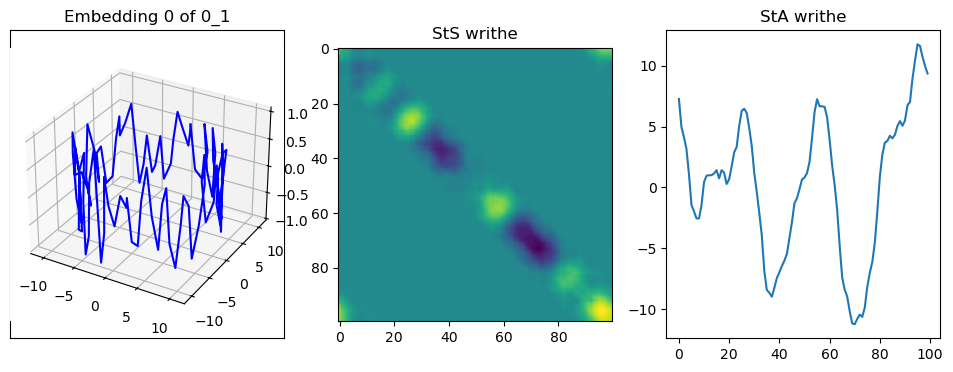

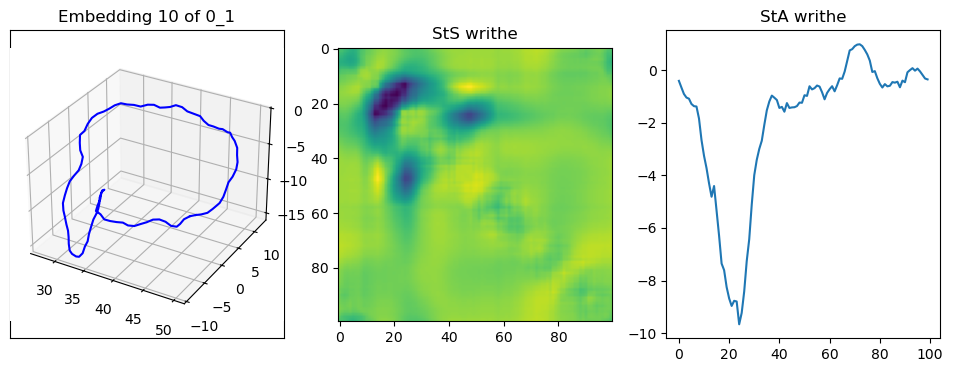

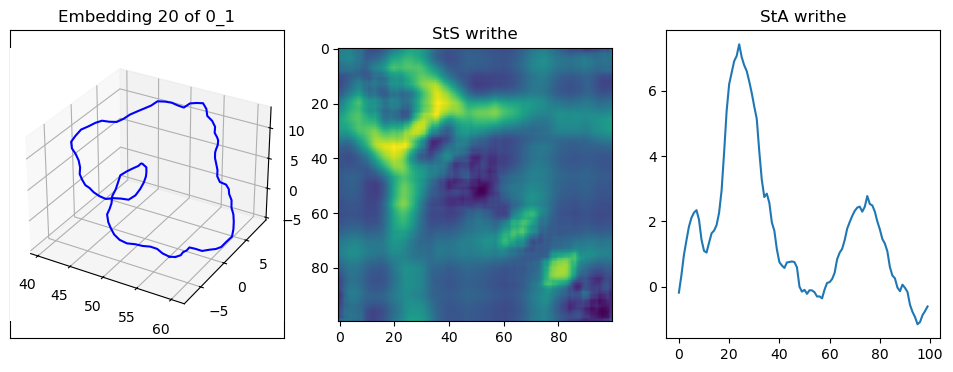

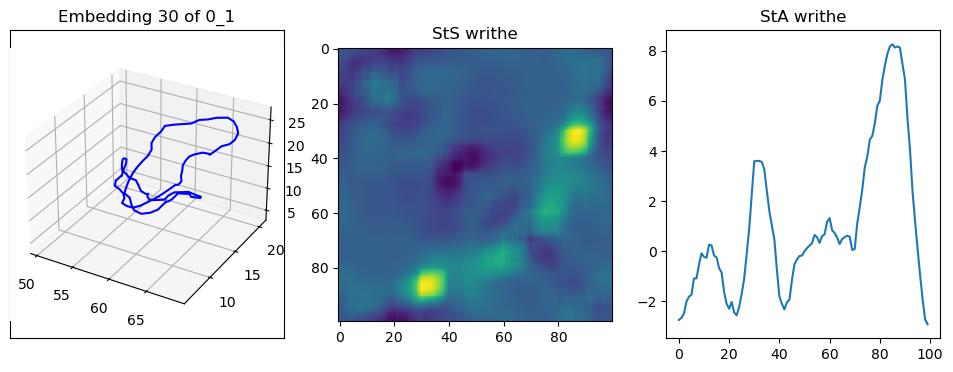

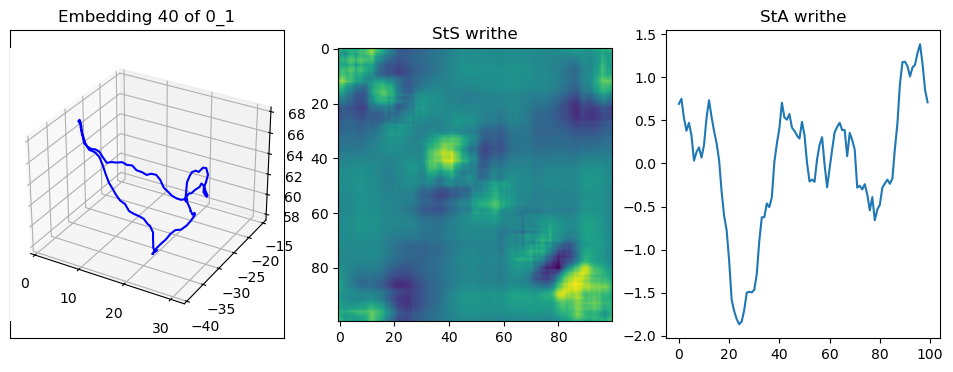

In [65]:
Nbeads = 100
n_cols = 3

data = data.reshape(-1, Nbeads, n_cols)

sample = 0

for i in range(0, 5):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    # Loop through each subplot

    axes_1 = fig.add_subplot(1, 3, 1, projection='3d') 

    single_knot = data[sample]

    single_knot_x = single_knot[:, 0]
    single_knot_y = single_knot[:, 1]
    single_knot_z = single_knot[:, 2]

    axes_1.plot(single_knot_x, single_knot_y, single_knot_z, color='b')

    last_seg_x = [single_knot_x[-1], single_knot_x[0]]
    last_seg_y = [single_knot_y[-1], single_knot_y[0]]
    last_seg_z = [single_knot_z[-1], single_knot_z[0]]

    axes_1.plot(last_seg_x, last_seg_y, last_seg_z, color='b')
    axes[0].set_title(f'Embedding {sample} of {knot}')

    axes[0].set_xticks([])
    axes[0].set_yticks([])


    writhe_matrix = compute_sts_writhe(single_knot, single_knot, 10)
    total = np.sum(writhe_matrix)

    im = axes[1].imshow(writhe_matrix)  # Display the matrix
    axes[1].set_title(f'StS writhe')


    STA = []
    for i in writhe_matrix:
        STA_point = 0

        for j in i:
            STA_point += j

        STA.append(STA_point)

    axes[2].plot(STA)
    axes[2].set_title(f"StA writhe")


    sample += 10

plt.show()

## Neural Networks ##

Now that we understand our data and its shape we can move on to building machine learning models to try and do meaningful things with our data.

We want to build a classic Feed-Forward Neural Network. For this to work we need to consider two things:

* The architecture of the network - its shape and size such that it can parse the data we give it properly.
    * We can initialize our architecture in a way that its has a general structure so that we define input and output size later, this lets us recycle the model architecture for different problems.
    * nn.Flatten() lets us turn our data, whatever its shape, into a 1D 'flattened' matrix, which is essential for the FFNN
* Activation functions between layers so that the network can learn non-linearly.

In [89]:
class FFNNModel(nn.Module):

    def __init__(self, inputs, outputs):
        super(FFNNModel, self).__init__()

        self.flatten_layer = nn.Flatten()
        self.dense_layer1 = nn.Linear(inputs, 300)
        self.dense_layer2 = nn.Linear(300, 300)
        self.output_layer = nn.Linear(300, outputs)

    def forward(self, x):

        x = self.flatten_layer(x)
        x = self.dense_layer1(x)
        x = F.relu(x)
        x = self.dense_layer2(x)
        x = F.relu(x)

        x = self.output_layer(x)

        return x

### Neural Networks: 2/2 ###

## Training, Validating and Testing ##

Now that our neural network model is built we want to specify how the training is done, luckily this is pretty simple.

Here we use PyTorch Lightning which reduces boilerplate code (essentially it reduces the amount of code we need to write if we want to build other neural network models by generalizing 'training', 'validating' and 'testing').

The steps here are to tell the neural network:
* How our data will be structured. This is different to the structure before, here we want to tell our model how the features (i.e. knot coordinates) and their labels (i.e. associated knot type) are to be passed into the model.
* What the forward step is: what set of layers and sizes are we passing our data through? (This is what we defined earlier)
* How and when do we define and apply the 'loss' for our problem, is it MSE, CCL?
* How do we evaluate the model post training?
* What optimizer do we need to use?

In [93]:
class NN(pl.LightningModule):
    def __init__(self, model, loss, opt):
        super().__init__()
        
        self.model = model
        self.loss = loss
        self.optimiser = opt

    def forward(self, x):
        # apply model layers
        x = self.model(x)
        return x

    def training_step(self, batch, batch_idx, loss_name = 'train_loss'):
        # training
        x,y = batch
        z = self.forward(x)
        loss = self.loss(z, y)
        self.log(loss_name, loss, on_epoch=True, on_step=True)
        return loss
    
    def validation_step(self, batch, batch_idx, loss_name = 'val_loss'):
        # validation
        x,y = batch
        z = self.forward(x)
        loss = self.loss(z, y)
        self.log(loss_name, loss, prog_bar=True, on_epoch=True, on_step=True)
        return loss
    
    def test_step(self, batch, batch_idx, loss_name ='test_loss'):

        # test
        # Now, revisit the structure we had for training and validation steps and replicate, specifically we need to pass the batch
        # and its x, y data into a forward pass and evaluate the loss

        inputs, targets = batch
        z = self.forward(inputs)
        loss = self.loss(z, targets)

        _, predicted = torch.max(z.data, 1) 
        test_acc = torch.sum(y == predicted).item() / (len(y)*1.0) 

        # log outputs
        self.log_dict({'test_loss': loss, 'test_acc': test_acc})

        return loss

    def configure_optimizers(self):
        return self.optimiser

### Train/Test/Val: 2/2 ###

## Initializing our newly built model ##

Now that we've built a model, and told it how to generally update, we can specifically define the following depending on what problem we would like to train our model on:
* The input shape of the model, is it a matrix of size (100, 3) defining the coordinates of a knot embedding? Or are we wanting to pass a measure we took on the knot?
* What loss function we want to use - defining how our model performance is evaluated.
* What optimizer we want to use - defining how our model is updated.

Lets start by training on the XYZ coordinates of the knot embedding

In [94]:
dtype = "XYZ"
knots = ["0_1", "3_1", "4_1", "5_1", "5_2"]

#Go back to this
input_shape = (300,)
output_shape = (1,)

FFNN = FFNNModel(input_shape[0], output_shape[0])
# (Make the appropriate loss function choice for a CLASSIFICATION problem: refer to PyTorch documentation if unsure)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(FFNN.parameters(), lr=0.001)

## Avoiding overfitting ##

A common problem with machine learning is overfitting to the data that it is being trained on, and therefore not being able to generalize beyond that, to mitigate this we implement 'early stopping'.
Early stopping checks our validation loss every epoch, which is the loss on a small partition of unseen data, not in our training dataset. It ensures that validation loss reduces along with training loss, ensuring the models capability to generalize. Specifically, here we define a 'patience (number of epochs)' in which our validation loss must decrease, if this doesnt occur the model terminates training.

Once this is addressed, we can pass our data through .fit(), training the model to predict based on training data and evaluating using validation data.

Next we pass our trained model through .test() to evaluate our model on unseen data.

In [95]:
def train(model, loss_fn, optimizer, train_loader, val_loader, test_loader, epochs):

    neural = NN(model=model, loss=loss_fn, opt=optimizer)

    # Early stopping defines metrics to ensure model doesn't overfit
    # min_delta is the minimum change in validation loss we require to say that the model has decreased loss in an epoch
    # patience is how many epochs we allow the model to run if the val_loss isnt going down. This count is reset each time the val_loss goes down
    # both these parameters will allow for better convergence

    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=0.001, patience=10, verbose=True, mode="min")
    trainer = Trainer(max_epochs=epochs, limit_train_batches=250, callbacks=[early_stop_callback])  # steps per epoch = 250

    # trainer.fit() fits data using training data and evaluates training using validation data
    # had the input requirements (model, training data, validation data)

    trainer.fit(neural, train_loader, val_loader)
                
    # trainer.test() tests data using test data 
    # requires the testing data

    trainer.test(dataloaders=test_loader)

    all_predicted = []
    all_y = []

    for x, y in test_loader:
        z = neural.forward(x)

        _, predicted = torch.max(z.data, 1) 
        test_acc = torch.sum(y == predicted).item() / (len(y)*1.0) 

        predicted_np = predicted.cpu().numpy()
        y_np = y.cpu().numpy()

        # Accumulate predictions
        all_predicted.extend(predicted_np)
        all_y.extend(y_np)

    # Calculate confusion matrix over all batches
    conf_mat = confusion_matrix(all_y, all_predicted)
    ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=knots).plot(include_values=False, cmap='Blues')

### Avoiding Overfitting: 0/1 ###
You've used the wrong loss function which is leading to the errors you are seeing. A more appropriate loss function wouldve been CategoricalCrossEntropy


## Putting everything together ##

Finally we can train a neural network to try and classify knots based on some input, first we will try with our coordinate data.

The code below tells us how to load our data and how to split it into train, validate and test subsets, before passing the required subsets into the training function defined above.
The code calls on another function defined in loader_basic.py that tells us how to load in all the data and structure it according to our needs.

In [96]:
len_db = 1000
bs = 256
directory = "data"
device = torch.device("cpu") 
datasets = []

for i, knot in enumerate(knots): 
    indicies = np.arange(0, len_db)
    datasets.append(Subset(KnotDataset(directory, dtype, knot, Nbeads, i), indicies))

dataset = ConcatDataset(datasets)

ninputs = len(dataset)

# Make an effective train/val/test split
train_len = int(ninputs * 0.6) 
test_len = int(ninputs * 0.2)
val_len = ninputs - (train_len + test_len)

train_dataset, test_dataset, val_dataset = split_train_test_validation(dataset, train_len, test_len, val_len, bs)

train(model = FFNN, loss_fn = loss_fn, optimizer = optimizer, train_loader = train_dataset, val_loader = val_dataset, test_loader= test_dataset, epochs = 10)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | FFNNModel         | 180 K  | train
1 | loss  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
180 K     Trainable params
0         Non-trainable params
180 K     Total params
0.724     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

ValueError: Target size (torch.Size([256])) must be the same as input size (torch.Size([256, 1]))

### Putting Everything Together: 1/1 ###

## Trying another input ## 

You should've seen that using the coordinates of the knot as input to the machine learning netwrok didn't perform particularly well (~80%). Now we will try do everything again but instead we will train on the calculated StA we saw earlier.

* Key thing to note is we will need to change our neural netwrok architecture shape as the data for StA is a 1 dimensional array (a line plot) as opposed to the 3d knot coordinate data.

In [78]:
dtype = "SIGWRITHE" # loading StA
knots = ["0_1", "3_1", "4_1", "5_1", "5_2"]

input_shape = (100,)
output_shape = (3,)

FFNN = FFNNModel(input_shape[0], output_shape[0])
loss_fn = nn.BCEWithLogitsLoss()
optimizer_ffnn = optim.Adam(FFNN.parameters(), lr=0.001)

## Retrain as required ##

With the new FFNN model we can retrain on our new data.

In [79]:
datasets = []

for i, knot in enumerate(knots): 
    indicies = np.arange(0, len_db)
    datasets.append(Subset(KnotDataset(directory, dtype, knot, Nbeads, i), indicies))

dataset = ConcatDataset(datasets)

ninputs = len(dataset)

# Make an effective train/val/test split
train_len = int(ninputs * 0.9)
test_len = int(ninputs * 0.075)
val_len = ninputs - (train_len + test_len)

train_dataset, test_dataset, val_dataset = split_train_test_validation(dataset, train_len, test_len, val_len, bs)

train(model = FFNN, loss_fn = loss_fn, optimizer = optimizer, train_loader = train_dataset, val_loader = val_dataset, test_loader= test_dataset, epochs = 10)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type              | Params | Mode 
----------------------------------------------------
0 | model | FFNNModel         | 121 K  | train
1 | loss  | BCEWithLogitsLoss | 0      | train
----------------------------------------------------
121 K     Trainable params
0         Non-trainable params
121 K     Total params
0.486     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\ls3007\.conda\envs\AGQenv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


ValueError: Target size (torch.Size([125])) must be the same as input size (torch.Size([125, 3]))

### Training another input: 0/1 ###
Similar issue with the loss function as above, also you need to be careful with using different variable names for different optimizers every time you run a model, otherwise you'll use 'pretrained' optimizer weights and the neural network wont be able to learn.

## Using "better" ML: LSTMs ##
The previous two times we ran our machine learning networks we varied the data being input, whilst using a fixed FFNN.
Unfortunately, FFNN's have limitations: One key limitation is their inability to capture sequential information.

The knot coordinates and StA writhe both encode sequential information, previous coordinates values depend on those before them in the sequence.
Long-Short Term Memory Neural Networks mitigate this issue by introducing a 'memory' state into the neural network.

Below we build an LSTM and see the performance increase on the StA data.
Although this in practice *should* be a better model than the FFNN for the data, we should actually observe a **decrease** in accuracy here. This is because we are using a small dataset, and LSTMs are particularly 'data hungry' in comparison to FFNNs.

This exercise shows the nuance in choosing the right model in accordance to the several variables at play e.g. data type and size in this case.

Additionally, we kept our learning rate the same as that used in the FFNN - try and explore other learning rates and see what happens to:
* The time taken to train
* Number of epochs until convergence
* Accuracy 

In [80]:
class LSTMModel(nn.Module):
    def __init__(self, input_shape, output_shape):
        super(LSTMModel, self).__init__()

        self.hidden_size = 128
        self.num_layers = 2
        self.seq = self.inp = input_shape[0]

        self.lstm = nn.LSTM(input_shape[1], self.hidden_size, self.num_layers, batch_first=True, bidirectional= False)
        self.fc = nn.Linear(hidden_size, output_)

    def forward(self, x):

        hidden = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device) 
        cell = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (hidden, cell)) 
        out = self.fc(out[:, -1, :])  
        
        return out

In [81]:
LSTM = LSTMModel(input_shape, output_shape)
loss_fn = nn.BCEWithLogitsLoss()
optimizer_lstm = optim.Adam(LSTM.parameters(), lr=0.001)

train(model = LSTM, loss_fn = loss_fn, optimizer = optimizer, train_loader = train_dataset, val_loader = val_dataset, test_loader= test_dataset, epochs = 10)

IndexError: tuple index out of range

### Better ML: 0.5/1 ###
Same issues as above but correct otherwise!

## Using "worse" ML: DT and KNN ##

Although we haven't covered the theory behind other machine learning models in this class, it is very important to acknowledge them. In (many) cases neural networks aren't the optimal solution and often lead to overfitting and unneccesarily long and resource intesive training. 

We won't cover too much theory here, however if you want to explore it a bit more there are plenty very good resources online. The main idea we would like to investigate is that ML is not restricted to neural networks and in many cases neural networks can be suboptimal to easier to train and simpler algorithms.

### Decision Trees ###

One type of machine learning method is the use of decision trees. The theory/mathematics is simple and can be covered in a short amount of time, with the general idea that we will separate our data based on creating 'if/else' statements that best separate the data.

```
Decision Tree Example:

                 [Start]
                    |
            feature X_{1}> 0.5
        -------------------------
        |                        |
       0_1                ------ No ------
                         feature X_{2}< 0.2
                         ------------------
                        |                  |
                       3_1                4_1
 ```

Without going into details; an algorithm is iterated through (the ML is trained) to minimize either the Gini impurity or entropy of the system at each node (end point) of the decision tree. 

$$Gini = 1 - \sum p_{i}^{2}$$
$$Entropy = -\sum p_{i}log p_{i}$$

$p_{i}$ is the probability of class $i$ at a given node.

There are several different algorithms for how the model evaluates different splittings and there entropy or gini impurity, 
for the interested student see the splitting algorithms CART and ID3: https://www.geeksforgeeks.org/decision-tree-algorithms/

The parameter we will be interested in changing is the depth of the tree, that is, how many subsequent if/else statements will we allow the tree to have.

### K-Nearest Neighbours ###

K-Nearest neighbours is another type of machine learning method. Again, the theory behind them is not difficult and can be covered easily, instead of using 'if/else' statements like Decision Trees, K-Nearest neighbour algorithms try to classify data by clustering datapoints that have similar features using some chosen metric (for example Euclidean distance).

The general idea is when trying to classify new a data point, we check the $n$ neighbours to the data point in feature space and assign a label to it based on which class represented the majority of its neighbours.

```
K-Nearest Neighbours Example:

                                      
y   ^                                  
    |        x  Z       o o          
    |                o          o  o 
    |     x                 o    o  
    |                    o           
    |    x   xx               o  o    
    |  x    x  x            o  o  o   
    |      x   x             oo  o    
    |   x x                             
    |      x  x                         
    |           x   x                   
    ------------------------------->    
                                      x  

 ```

 In the above example we can see that the 5 nearest neighbours for a new point $Z$ based on a euclidean distance would be (x, x, o, o, o). Hence, as the majority of neighbours are of the class o $Z$ will be classified by the KNN model as having the same label as $o$. Clearly the choice of number of neighbours is imperitive to the classification as had we specified 1 nearest neighbour, $X$ would be classified as being in the class x.

See https://www.geeksforgeeks.org/k-nearest-neighbours/ for more information.

In [75]:
class AlternativeML:
    '''
    
    This class builds a Decision Tree classifier (https://scikit-learn.org/stable/modules/tree.html)
    The __init__ function will ensure that our pre-loaded data is of the right shapes and data type; for our purposes we will ignore it.
    The classification function is where our Decision Tree code lives, all of the details are included on the link above and we just need to provide the training
    and testing data as required.

    '''
    def __init__(self, train_data, test_data):
        self.X_train = []
        self.y_train = []
        self.train_data = train_data
        for X, y in self.train_data:
            X = [i.numpy().flatten() for i in X]
            self.X_train.append(X)
            self.y_train.append(y.numpy())

        self.X_train = list(itertools.chain.from_iterable(self.X_train))
        self.y_train = list(itertools.chain.from_iterable(self.y_train))

        self.X_test = []
        self.y_test = []
        self.test_data = test_data
        for X, y in self.test_data:
            X = [i.numpy().flatten() for i in X]
            self.X_test.append(X)
            self.y_test.append(y.numpy())

        self.X_test = list(itertools.chain.from_iterable(self.X_test))
        self.y_test = list(itertools.chain.from_iterable(self.y_test))

    def DTclassifier(self):

        print("training decision tree model...")
        clf = tree.DecisionTreeClassifier(max_depth=5)
        clf = clf.fit(self.X_train, self.y_train)
        filename = f'DT.sav'
        pickle.dump(clf, open(filename, 'wb'))

        print("loading decision tree model...")

        clf = pickle.load(open(f'DT.sav', 'rb'))

        y_pred = clf.predict(self.X_test, self.y_test)
        score = accuracy_score(y_pred=y_pred, y_true=self.y_test)
        conf_mat = confusion_matrix(y_pred=y_pred, y_true=self.y_test)
        print(f"DT Accuracy: {score*100}%")
        print(conf_mat)
        ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=knots).plot(include_values=False, cmap='Blues')
        plt.show()

    def KNNclassifier(self):
        
        print("training...")
        clf = neighbors.KNeighborsClassifier(n_neighbors=3)
        clf = clf.fit(self.X_train, self.y_train)
        filename = f'KNN.sav'
        pickle.dump(clf, open(filename, 'wb'))

        print("loading model...")

        clf = pickle.load(open(f'KNN.sav', 'rb'))

        y_pred = clf.predict(self.X_test)
        score = accuracy_score(y_pred=y_pred, y_true=self.y_test)
        conf_mat = confusion_matrix(y_pred=y_pred, y_true=self.y_test)
        print(f"KNN Accuracy: {score*100}%")
        print(conf_mat)
        ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=knots).plot(include_values=False, cmap='Blues')
        plt.show()



training decision tree model...
loading decision tree model...
DT Accuracy: 66.13333333333333%
[[60  5  7  0  0]
 [ 1 44  1 13 12]
 [ 4  7 71  0  0]
 [ 0 10  0 41 22]
 [ 0 39  0  6 32]]


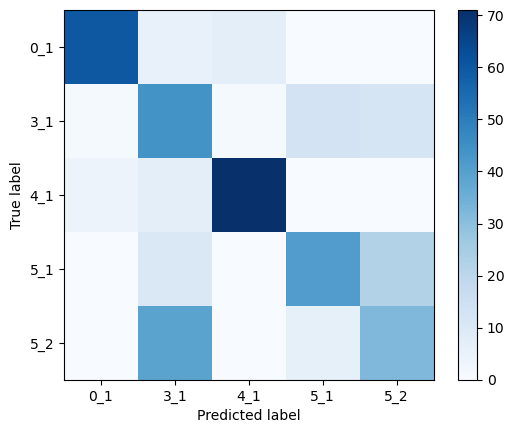

In [76]:
AltML = AlternativeML(train_dataset, test_dataset)
AltML.DTclassifier()

training...
loading model...
KNN Accuracy: 96.8%
[[72  0  0  0  0]
 [ 0 68  0  0  3]
 [ 0  0 82  0  0]
 [ 0  0  0 72  1]
 [ 0  6  0  2 69]]


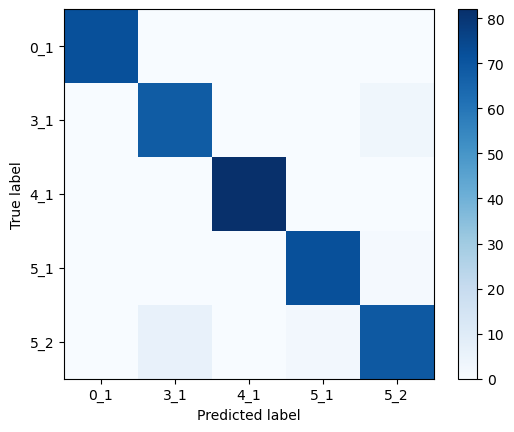

In [77]:
AltML.KNNclassifier()

### Worse ML: 1/1 ###